In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)

In [2]:
file_path = "../data/processed/it_support_tickets_cleaned.csv"

df = pd.read_csv(file_path)

df.head()

,ticket_id,created_at,customer_id,customer_segment,channel,product_area,issue_type,priority,status,sla_plan,initial_message,agent_first_reply,resolution_summary,resolution_time_hours,reopened,customer_sentiment,csat_score,has_attachment,platform,region,created_year,created_month,created_month_name,created_quarter,is_resolved,is_unresolved
0,TCKT_000001,2024-01-31 05:14:27,CUST_00861,individual,email,data_export,account_access,low,resolved,standard,I cannot log in; the system says my password is incorrect.,Sorry to hear you're having trouble accessing your account. We will look into this and get back ...,Reset account credentials and confirmed successful login.,36.53,0,very_negative,1,0,android,EU,2024,1,January,1,True,False
1,TCKT_000002,2024-10-20 06:15:49,CUST_00770,individual,in_app,billing,security_concern,medium,closed_no_action,standard,I noticed a suspicious login on my account.,We take security very seriously. Our team is reviewing this and will follow up within 24 hours.,Ticket closed without further action after no response from the customer.,238.32,0,neutral,3,0,web,Unknown,2024,10,October,4,True,False
2,TCKT_000003,2024-06-18 21:35:54,CUST_02559,small_business,chat,api_integration,bug,low,in_progress,standard,The api integration feature is not saving my changes.,Thanks for reporting this bug. We will look into this and get back to you within the next 48 hours.,Not yet resolved,NaN,0,neutral,3,0,android,MEA,2024,6,June,2,False,True
3,TCKT_000004,2025-12-25 15:59:52,CUST_03557,education,chat,analytics_dashboard,account_access,medium,in_progress,standard,I cannot log in; the system says my password is incorrect.,Sorry to hear you're having trouble accessing your account. Our team is reviewing this and will ...,Not yet resolved,NaN,0,positive,5,1,android,LATAM,2025,12,December,4,False,True
4,TCKT_000005,2023-08-27 16:08:33,CUST_09556,enterprise,phone_transcript,login_auth,billing_problem,low,resolved,gold,My invoice amount is incorrect compared to the plan I selected.,Thanks for reaching out about the billing issue. We will look into this and get back to you with...,Adjusted the invoice and issued a refund where applicable.,61.32,0,very_negative,2,0,web,Unknown,2023,8,August,3,True,False


In [3]:
df.shape

(10000, 26)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ticket_id              10000 non-null  object 
 1   created_at             10000 non-null  object 
 2   customer_id            10000 non-null  object 
 3   customer_segment       10000 non-null  object 
 4   channel                10000 non-null  object 
 5   product_area           10000 non-null  object 
 6   issue_type             10000 non-null  object 
 7   priority               10000 non-null  object 
 8   status                 10000 non-null  object 
 9   sla_plan               10000 non-null  object 
 10  initial_message        10000 non-null  object 
 11  agent_first_reply      10000 non-null  object 
 12  resolution_summary     10000 non-null  object 
 13  resolution_time_hours  5954 non-null   float64
 14  reopened               10000 non-null  int64  
 15  cus

# Ticket and SLA Analysis

## Objective

The purpose of this notebook is to analyze IT support ticket performance using the cleaned support ticket dataset. The analysis focuses on ticket volume, SLA performance, resolution time, ticket status, priority levels, support channels, customer sentiment, and operational bottlenecks.

This notebook is designed to answer practical business questions such as:

- How many tickets were created over time?
- Which ticket statuses are most common?
- Which priorities generate the most support workload?
- Which channels receive the most support tickets?
- How does resolution time vary by priority, SLA plan, and issue type?
- What patterns can help support teams improve operational performance?

In [5]:
# Confirm key fields for analysis
df[[
    "ticket_id",
    "created_at",
    "status",
    "priority",
    "sla_plan",
    "resolution_time_hours",
    "channel",
    "product_area",
    "issue_type",
    "customer_sentiment",
    "csat_score",
    "region",
    "is_resolved",
    "is_unresolved"
]].head()

,ticket_id,created_at,status,priority,sla_plan,resolution_time_hours,channel,product_area,issue_type,customer_sentiment,csat_score,region,is_resolved,is_unresolved
0,TCKT_000001,2024-01-31 05:14:27,resolved,low,standard,36.53,email,data_export,account_access,very_negative,1,EU,True,False
1,TCKT_000002,2024-10-20 06:15:49,closed_no_action,medium,standard,238.32,in_app,billing,security_concern,neutral,3,Unknown,True,False
2,TCKT_000003,2024-06-18 21:35:54,in_progress,low,standard,NaN,chat,api_integration,bug,neutral,3,MEA,False,True
3,TCKT_000004,2025-12-25 15:59:52,in_progress,medium,standard,NaN,chat,analytics_dashboard,account_access,positive,5,LATAM,False,True
4,TCKT_000005,2023-08-27 16:08:33,resolved,low,gold,61.32,phone_transcript,login_auth,billing_problem,very_negative,2,Unknown,True,False


In [6]:
# Ticket volume by status
status_counts = df["status"].value_counts().reset_index()
status_counts.columns = ["status", "ticket_count"]

status_counts

,status,ticket_count
0,resolved,5014
1,in_progress,2020
2,on_hold,1029
3,open,997
4,closed_no_action,940


In [7]:
# Ticket volume by status as percentage
status_summary = df["status"].value_counts(normalize=True).mul(100).round(2).reset_index()
status_summary.columns = ["status", "percentage"]

status_summary

,status,percentage
0,resolved,50.14
1,in_progress,20.20
2,on_hold,10.29
3,open,9.97
4,closed_no_action,9.40


## Ticket Volume by Status

This section analyzes the distribution of IT support tickets by status. The goal is to understand how many tickets are resolved, still in progress, open, on hold, or closed without action.

This helps identify the overall operational health of the support process. A high number of unresolved tickets may indicate workload pressure, SLA risk, staffing gaps, or process bottlenecks.

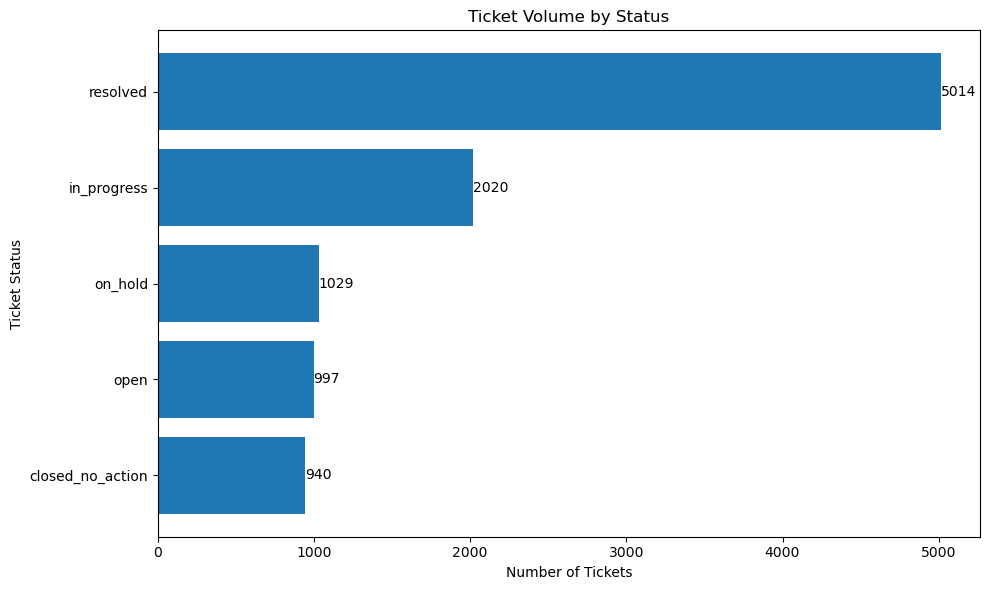

In [8]:
import matplotlib.pyplot as plt

# Sort status counts for chart
status_counts_sorted = status_counts.sort_values("ticket_count", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(status_counts_sorted["status"], status_counts_sorted["ticket_count"])

plt.title("Ticket Volume by Status")
plt.xlabel("Number of Tickets")
plt.ylabel("Ticket Status")

for index, value in enumerate(status_counts_sorted["ticket_count"]):
    plt.text(value, index, str(value), va="center")

plt.tight_layout()
plt.show()

### Key Insight

The majority of tickets are resolved, accounting for 5,014 tickets or 50.14% of the dataset. This suggests that the support process is closing a significant portion of reported issues.

However, 2,020 tickets are still in progress, while another 997 remain open and 1,029 are on hold. Together, these unresolved or pending categories represent a large operational workload. This may indicate areas where support teams need better prioritization, faster escalation, or improved resolution processes.

The 940 closed_no_action tickets should also be reviewed further because they may represent tickets where the customer did not respond, the issue was invalid, or the support team closed the case without a full resolution.

## SLA Performance Analysis

This section analyzes ticket resolution performance based on the SLA plan. The goal is to understand whether different SLA tiers have different ticket volumes and resolution times.

This is important because SLA plans usually represent different service expectations. For example, platinum or gold customers may be expected to receive faster support than standard customers.

In [9]:
# Ticket volume by SLA plan
sla_counts = df["sla_plan"].value_counts().reset_index()
sla_counts.columns = ["sla_plan", "ticket_count"]

sla_counts

,sla_plan,ticket_count
0,standard,5974
1,gold,3048
2,platinum,978


In [10]:
# Average resolution time by SLA plan
sla_resolution = df.groupby("sla_plan")["resolution_time_hours"].mean().round(2).reset_index()
sla_resolution.columns = ["sla_plan", "avg_resolution_time_hours"]

sla_resolution

,sla_plan,avg_resolution_time_hours
0,gold,44.79
1,platinum,44.87
2,standard,42.35


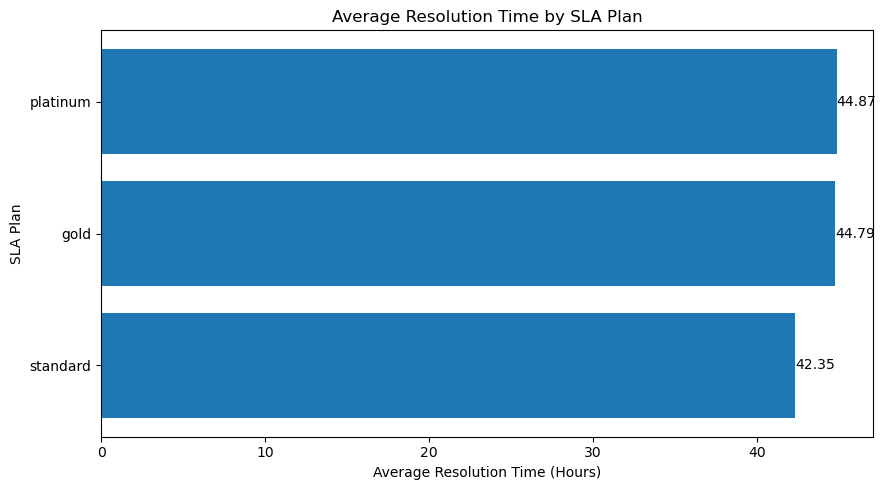

In [11]:
# Chart: Average resolution time by SLA plan
import matplotlib.pyplot as plt

sla_resolution_sorted = sla_resolution.sort_values("avg_resolution_time_hours", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(
    sla_resolution_sorted["sla_plan"],
    sla_resolution_sorted["avg_resolution_time_hours"]
)

plt.title("Average Resolution Time by SLA Plan")
plt.xlabel("Average Resolution Time (Hours)")
plt.ylabel("SLA Plan")

for index, value in enumerate(sla_resolution_sorted["avg_resolution_time_hours"]):
    plt.text(value, index, str(value), va="center")

plt.tight_layout()
plt.show()

### Key Insight

The SLA analysis shows that standard tickets make up the largest share of the workload with 5,974 tickets, followed by gold with 3,048 tickets and platinum with 978 tickets.

Interestingly, the standard SLA plan has the lowest average resolution time at 42.35 hours, while gold and platinum tickets have slightly higher average resolution times of 44.79 and 44.87 hours respectively. This suggests that premium SLA tiers are not being resolved faster than standard tickets in this dataset.

From an operations perspective, this could indicate a potential SLA performance gap. If gold and platinum customers are expected to receive faster support, the support team may need to review ticket routing, priority handling, escalation rules, and agent assignment for premium customers.

## Priority Analysis

This section analyzes ticket distribution and resolution performance by ticket priority. The goal is to understand whether higher-priority tickets are being resolved faster than lower-priority tickets.

This is important because priority levels should guide how quickly tickets are handled. High-priority tickets should ideally receive faster attention and shorter resolution times than medium or low-priority tickets.

In [12]:
# Ticket volume by priority
priority_counts = df["priority"].value_counts().reset_index()
priority_counts.columns = ["priority", "ticket_count"]

priority_counts

,priority,ticket_count
0,low,3907
1,medium,3566
2,high,1998
3,urgent,529


In [13]:
# Average resolution time by priority
priority_resolution = df.groupby("priority")["resolution_time_hours"].mean().round(2).reset_index()
priority_resolution.columns = ["priority", "avg_resolution_time_hours"]

priority_resolution

,priority,avg_resolution_time_hours
0,high,30.37
1,low,54.38
2,medium,41.80
3,urgent,22.00


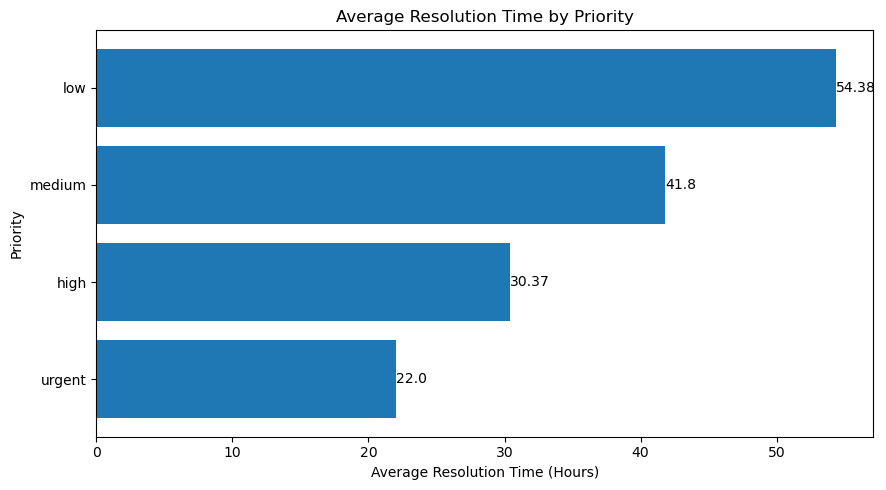

In [14]:
# Chart: Average resolution time by priority
import matplotlib.pyplot as plt

priority_resolution_sorted = priority_resolution.sort_values("avg_resolution_time_hours", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(
    priority_resolution_sorted["priority"],
    priority_resolution_sorted["avg_resolution_time_hours"]
)

plt.title("Average Resolution Time by Priority")
plt.xlabel("Average Resolution Time (Hours)")
plt.ylabel("Priority")

for index, value in enumerate(priority_resolution_sorted["avg_resolution_time_hours"]):
    plt.text(value, index, str(value), va="center")

plt.tight_layout()
plt.show()

### Key Insight

Low-priority tickets make up the largest share of the workload with 3,907 tickets, followed by medium-priority tickets with 3,566 tickets. High-priority tickets account for 1,998 tickets, while urgent tickets are the smallest group with 529 tickets.

The average resolution time follows the expected priority pattern. Urgent tickets have the fastest average resolution time at 22.00 hours, followed by high-priority tickets at 30.37 hours. Medium-priority tickets take 41.80 hours on average, while low-priority tickets take the longest at 54.38 hours.

This suggests that the support team is generally prioritizing tickets correctly. Higher-priority tickets are receiving faster attention and resolution, while lower-priority tickets remain open for longer. From an operational perspective, this is a positive sign because it shows that urgency and priority levels are influencing ticket handling.

## Customer Sentiment Analysis

This section analyzes how customers feel about their support experience. Customer sentiment helps identify whether users are satisfied, neutral, or dissatisfied with the service they received.

This is important because support performance should not only be measured by ticket volume or resolution time. A ticket can be resolved quickly but still leave the customer unhappy. By analyzing sentiment alongside CSAT score and resolution time, we can better understand the customer experience.

In [15]:
# Customer sentiment distribution
sentiment_counts = df["customer_sentiment"].value_counts().reset_index()
sentiment_counts.columns = ["customer_sentiment", "ticket_count"]

sentiment_counts

,customer_sentiment,ticket_count
0,neutral,3160
1,negative,2636
2,very_negative,1695
3,positive,1653
4,very_positive,856


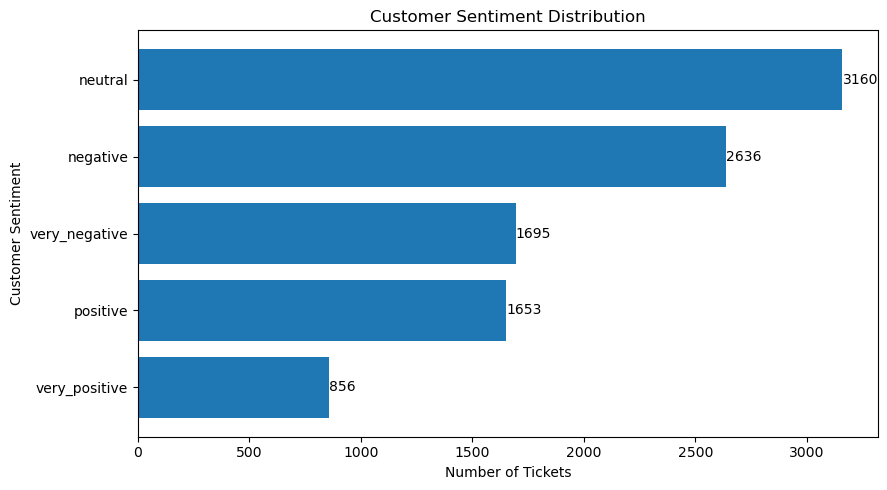

In [16]:
# Chart: Customer sentiment distribution
import matplotlib.pyplot as plt

sentiment_counts_sorted = sentiment_counts.sort_values("ticket_count", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(
    sentiment_counts_sorted["customer_sentiment"],
    sentiment_counts_sorted["ticket_count"]
)

plt.title("Customer Sentiment Distribution")
plt.xlabel("Number of Tickets")
plt.ylabel("Customer Sentiment")

for index, value in enumerate(sentiment_counts_sorted["ticket_count"]):
    plt.text(value, index, str(value), va="center")

plt.tight_layout()
plt.show()

### Key Insight

The customer sentiment analysis shows that neutral sentiment is the largest category, with 3,160 tickets. This suggests that many customers had average or mixed support experiences rather than clearly positive or negative ones.

However, negative sentiment is also high, with 2,636 tickets, and very negative sentiment accounts for another 1,695 tickets. Together, negative and very negative tickets represent a major share of the dataset, which may indicate customer dissatisfaction, unresolved expectations, slow resolution, or poor communication during the support process.

Positive sentiment appears in 1,653 tickets, while very positive sentiment appears in only 856 tickets. This means strongly positive customer experiences are much less common than neutral or negative experiences.

From an operational perspective, the support team should investigate the causes of negative and very negative sentiment. These tickets may reveal patterns related to long resolution times, specific issue types, SLA failures, or weak agent responses.

## CSAT Score Analysis

This section analyzes customer satisfaction scores across the IT support tickets. CSAT score helps measure how satisfied customers were with the support experience after interacting with the support team.

This is important because ticket resolution speed alone does not fully explain service quality. A ticket may be resolved quickly, but the customer may still be unhappy if the communication, process, or final outcome was poor.

In [17]:
# CSAT score distribution
csat_counts = df["csat_score"].value_counts().sort_index().reset_index()
csat_counts.columns = ["csat_score", "ticket_count"]

csat_counts

,csat_score,ticket_count
0,0,3007
1,1,603
2,2,1494
3,3,2013
4,4,1717
5,5,1166


In [18]:
# Average CSAT score by ticket status
csat_by_status = df.groupby("status")["csat_score"].mean().round(2).reset_index()
csat_by_status.columns = ["status", "avg_csat_score"]

csat_by_status

,status,avg_csat_score
0,closed_no_action,2.19
1,in_progress,2.20
2,on_hold,2.26
3,open,2.23
4,resolved,2.25


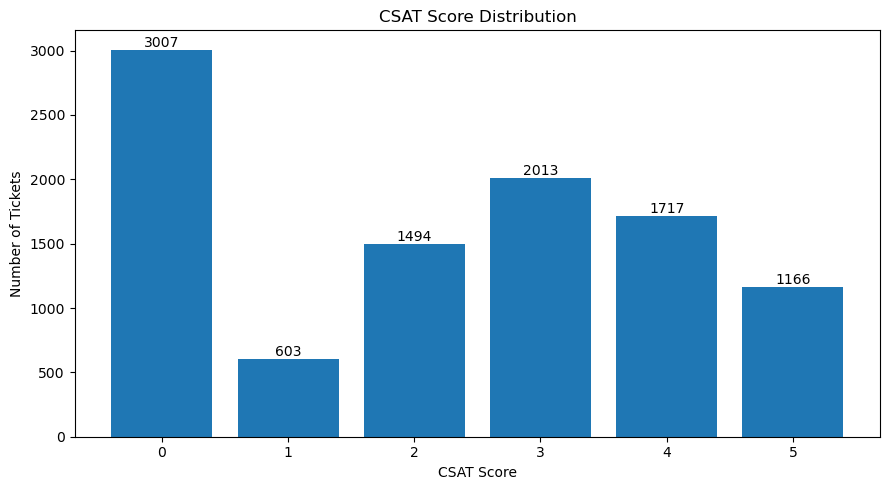

In [19]:
# Chart: CSAT score distribution
import matplotlib.pyplot as plt

csat_counts_sorted = csat_counts.sort_values("csat_score")

plt.figure(figsize=(9, 5))
plt.bar(
    csat_counts_sorted["csat_score"].astype(str),
    csat_counts_sorted["ticket_count"]
)

plt.title("CSAT Score Distribution")
plt.xlabel("CSAT Score")
plt.ylabel("Number of Tickets")

for index, value in enumerate(csat_counts_sorted["ticket_count"]):
    plt.text(index, value, str(value), ha="center", va="bottom")

plt.tight_layout()
plt.show()

### Key Insight

The CSAT score analysis shows that the largest group of tickets received a CSAT score of 0, with 3,007 tickets. This is a major concern because it suggests that a significant number of customers had very poor support experiences or did not receive a satisfactory outcome.

The next largest group is CSAT score 3, with 2,013 tickets, followed by score 4 with 1,717 tickets and score 2 with 1,494 tickets. Only 1,166 tickets received the highest CSAT score of 5, while 603 tickets received a score of 1.

The average CSAT score by ticket status is also low across all categories, ranging from 2.19 to 2.26. Resolved tickets have an average CSAT score of only 2.25, which suggests that closing a ticket does not necessarily mean the customer was satisfied.

From an operational perspective, the support team should investigate why many tickets are receiving low satisfaction scores. Possible causes may include poor communication, slow updates, weak resolution quality, unresolved customer expectations, or tickets being closed before the customer feels the issue was fully addressed.

## Channel Analysis

This section analyzes how tickets are distributed across different support channels. The goal is to understand where most customer support requests are coming from.

This is important because different channels may create different types of workload. For example, email tickets may take longer to resolve than chat tickets, while phone tickets may require faster response and stronger agent availability.

In [20]:
# Ticket volume by support channel
channel_counts = df["channel"].value_counts().reset_index()
channel_counts.columns = ["channel", "ticket_count"]

channel_counts

,channel,ticket_count
0,email,2048
1,phone_transcript,2037
2,web_form,2011
3,chat,1958
4,in_app,1946


In [21]:
# Average resolution time by support channel
channel_resolution = df.groupby("channel")["resolution_time_hours"].mean().round(2).reset_index()
channel_resolution.columns = ["channel", "avg_resolution_time_hours"]

channel_resolution

,channel,avg_resolution_time_hours
0,chat,46.02
1,email,42.69
2,in_app,42.99
3,phone_transcript,43.22
4,web_form,41.80


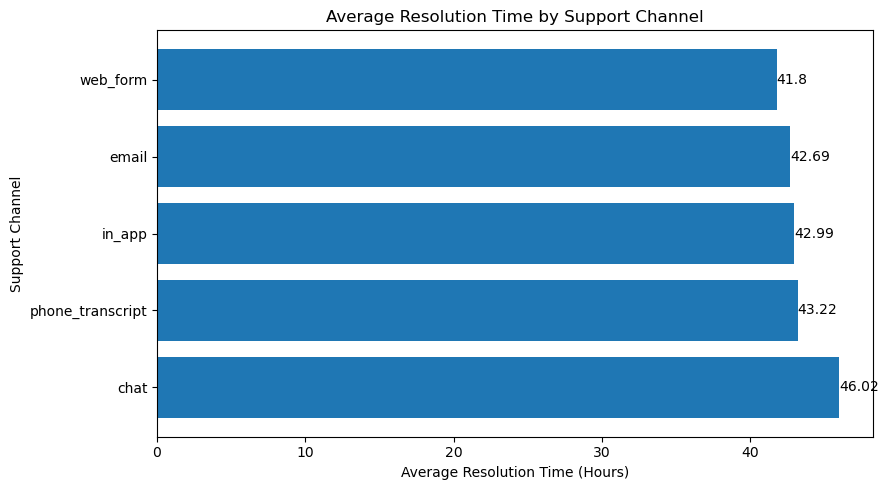

In [22]:
# Chart: Average resolution time by support channel
import matplotlib.pyplot as plt

channel_resolution_sorted = channel_resolution.sort_values("avg_resolution_time_hours", ascending=False)

plt.figure(figsize=(9, 5))
plt.barh(
    channel_resolution_sorted["channel"],
    channel_resolution_sorted["avg_resolution_time_hours"]
)

plt.title("Average Resolution Time by Support Channel")
plt.xlabel("Average Resolution Time (Hours)")
plt.ylabel("Support Channel")

for index, value in enumerate(channel_resolution_sorted["avg_resolution_time_hours"]):
    plt.text(value, index, str(value), va="center")

plt.tight_layout()
plt.show()

### Key Insight

Ticket volume is fairly evenly distributed across all support channels. Email has the highest volume with 2,048 tickets, followed closely by phone transcript with 2,037 tickets and web form with 2,011 tickets. Chat and in-app tickets are slightly lower, with 1,958 and 1,946 tickets respectively.

The average resolution time differs more clearly across channels. Chat tickets have the longest average resolution time at 46.02 hours, while web form tickets have the shortest average resolution time at 41.80 hours. Email, in-app, and phone transcript tickets fall between 42.69 and 43.22 hours.

From an operational perspective, chat appears to be a potential bottleneck. Even though chat is often expected to provide faster support, it has the longest average resolution time in this dataset. The support team may need to review chat staffing, routing rules, escalation processes, or the complexity of issues coming through the chat channel.

## Product Area Analysis

This section analyzes how support tickets are distributed across different product areas. The goal is to identify which parts of the product generate the most support workload.

This is important because a high number of tickets in a product area may indicate usability issues, product defects, confusing features, weak documentation, or areas where customers need more guidance.

In [23]:
# Ticket volume by product area
product_counts = df["product_area"].value_counts().reset_index()
product_counts.columns = ["product_area", "ticket_count"]

product_counts

,product_area,ticket_count
0,analytics_dashboard,1486
1,api_integration,1434
2,mobile_app,1434
3,data_export,1420
4,billing,1411
5,login_auth,1411
6,notifications,1404


In [24]:
# Average resolution time by product area
product_resolution = df.groupby("product_area")["resolution_time_hours"].mean().round(2).reset_index()
product_resolution.columns = ["product_area", "avg_resolution_time_hours"]

product_resolution

,product_area,avg_resolution_time_hours
0,analytics_dashboard,44.39
1,api_integration,42.56
2,billing,45.56
3,data_export,41.64
4,login_auth,40.65
5,mobile_app,46.48
6,notifications,41.92


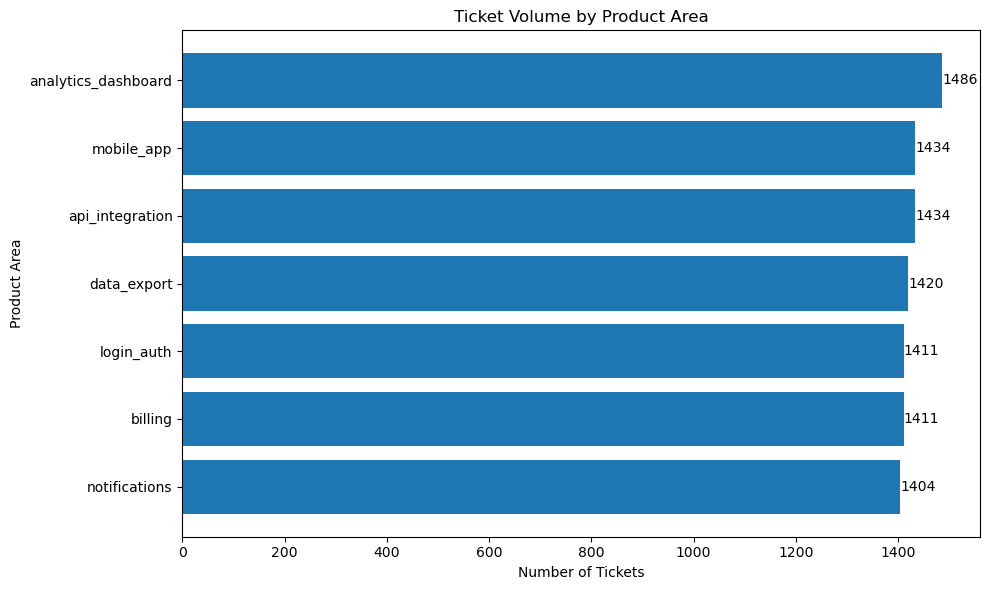

In [25]:
# Chart: Ticket volume by product area
import matplotlib.pyplot as plt

product_counts_sorted = product_counts.sort_values("ticket_count", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(
    product_counts_sorted["product_area"],
    product_counts_sorted["ticket_count"]
)

plt.title("Ticket Volume by Product Area")
plt.xlabel("Number of Tickets")
plt.ylabel("Product Area")

for index, value in enumerate(product_counts_sorted["ticket_count"]):
    plt.text(value, index, str(value), va="center")

plt.tight_layout()
plt.show()

### Key Insight

Ticket volume is fairly evenly distributed across all product areas. The analytics dashboard has the highest number of tickets with 1,486 tickets, followed by mobile app and API integration with 1,434 tickets each. Notifications has the lowest ticket volume with 1,404 tickets.

Average resolution time varies more clearly by product area. Mobile app has the longest average resolution time at 46.48 hours, followed by billing at 45.56 hours and analytics dashboard at 44.39 hours. Login/auth has the shortest average resolution time at 40.65 hours.

From an operational perspective, mobile app and billing should be reviewed more closely because they take longer to resolve. This may indicate more complex issues, product defects, unclear workflows, or the need for stronger documentation and escalation processes in those product areas.

## Issue Type Analysis

This section analyzes support tickets by issue type. The goal is to identify which types of customer problems occur most often and which ones take the longest to resolve.

This is important because issue type analysis helps the support team understand the root causes of ticket volume. If certain issue types are more frequent or take longer to resolve, the company can improve product design, documentation, self-service support, or escalation workflows.

In [26]:
# Ticket volume by issue type
issue_counts = df["issue_type"].value_counts().reset_index()
issue_counts.columns = ["issue_type", "ticket_count"]

issue_counts

,issue_type,ticket_count
0,security_concern,1332
1,how_to,1325
2,performance,1232
3,account_access,1228
4,bug,1226
5,feature_request,1225
6,billing_problem,1217
7,other,1215


In [27]:
# Average resolution time by issue type
issue_resolution = df.groupby("issue_type")["resolution_time_hours"].mean().round(2).reset_index()
issue_resolution.columns = ["issue_type", "avg_resolution_time_hours"]

issue_resolution

,issue_type,avg_resolution_time_hours
0,account_access,42.65
1,billing_problem,43.45
2,bug,44.24
3,feature_request,43.34
4,how_to,44.80
5,other,41.53
6,performance,43.16
7,security_concern,43.36


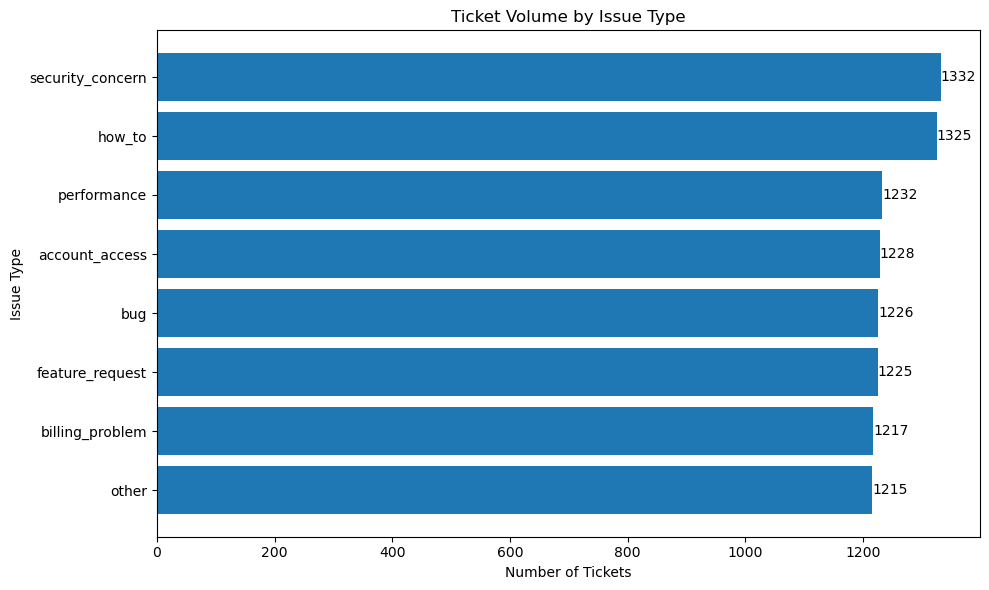

In [28]:
# Chart: Ticket volume by issue type
import matplotlib.pyplot as plt

issue_counts_sorted = issue_counts.sort_values("ticket_count", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(
    issue_counts_sorted["issue_type"],
    issue_counts_sorted["ticket_count"]
)

plt.title("Ticket Volume by Issue Type")
plt.xlabel("Number of Tickets")
plt.ylabel("Issue Type")

for index, value in enumerate(issue_counts_sorted["ticket_count"]):
    plt.text(value, index, str(value), va="center")

plt.tight_layout()
plt.show()

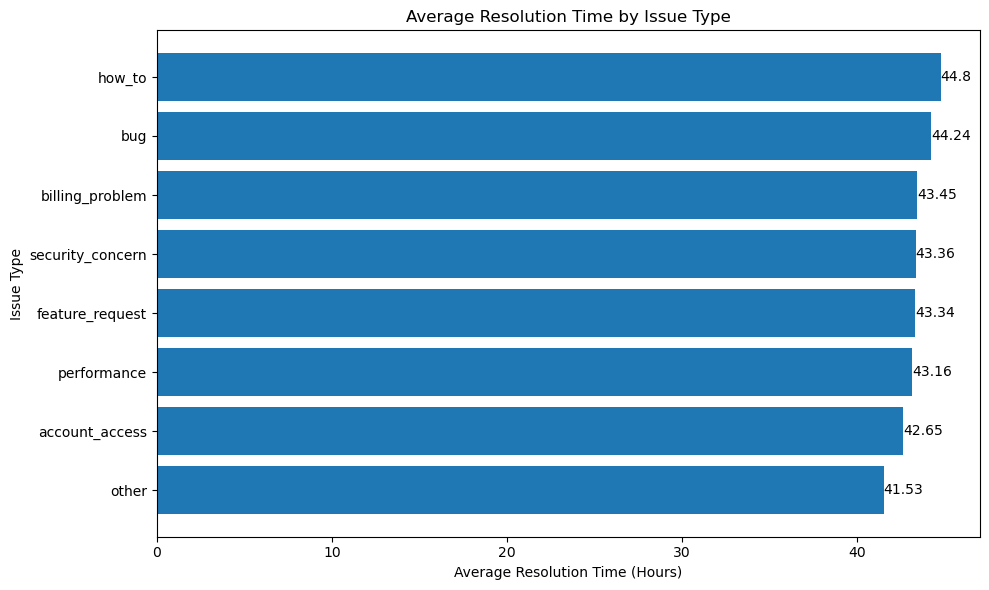

In [29]:
# Chart: Average resolution time by issue type
issue_resolution_sorted = issue_resolution.sort_values("avg_resolution_time_hours", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(
    issue_resolution_sorted["issue_type"],
    issue_resolution_sorted["avg_resolution_time_hours"]
)

plt.title("Average Resolution Time by Issue Type")
plt.xlabel("Average Resolution Time (Hours)")
plt.ylabel("Issue Type")

for index, value in enumerate(issue_resolution_sorted["avg_resolution_time_hours"]):
    plt.text(value, index, str(value), va="center")

plt.tight_layout()
plt.show()

### Key Insight

Ticket volume is fairly evenly distributed across issue types, but security concern has the highest number of tickets with 1,332 tickets, followed closely by how-to issues with 1,325 tickets. The lowest ticket volume is in the other category, with 1,215 tickets.

Average resolution time varies slightly across issue types. How-to tickets take the longest to resolve at 44.80 hours, followed by bug tickets at 44.24 hours and billing problem tickets at 43.45 hours. The other category has the shortest average resolution time at 41.53 hours.

From an operational perspective, how-to and bug-related tickets should be reviewed more closely because they take longer to resolve. This may indicate gaps in documentation, self-service resources, product usability, or technical troubleshooting workflows.

## Operational Summary

This section summarizes the main operational findings from the ticket analysis. The goal is to bring together the key metrics from ticket volume, resolution performance, customer satisfaction, support channels, product areas, and issue types.

This summary helps support leaders quickly understand where the support operation is performing well and where improvement may be needed.

In [30]:
# Overall operational summary metrics

total_tickets = len(df)

resolved_tickets = df[df["status"] == "resolved"].shape[0]
open_tickets = df[df["status"] == "open"].shape[0]
in_progress_tickets = df[df["status"] == "in_progress"].shape[0]
on_hold_tickets = df[df["status"] == "on_hold"].shape[0]

avg_resolution_time = round(df["resolution_time_hours"].mean(), 2)
avg_csat_score = round(df["csat_score"].mean(), 2)

summary_metrics = {
    "total_tickets": total_tickets,
    "resolved_tickets": resolved_tickets,
    "open_tickets": open_tickets,
    "in_progress_tickets": in_progress_tickets,
    "on_hold_tickets": on_hold_tickets,
    "avg_resolution_time_hours": avg_resolution_time,
    "avg_csat_score": avg_csat_score
}

summary_metrics

{'total_tickets': 10000,
 'resolved_tickets': 5014,
 'open_tickets': 997,
 'in_progress_tickets': 2020,
 'on_hold_tickets': 1029,
 'avg_resolution_time_hours': np.float64(43.33),
 'avg_csat_score': np.float64(2.23)}

### Key Insight

The overall dataset contains 10,000 support tickets. Out of these, 5,014 tickets are resolved, meaning just over half of all tickets have been completed. However, there are still 997 open tickets, 2,020 tickets in progress, and 1,029 tickets on hold. This means a significant portion of the workload is still active or pending.

The average resolution time across all tickets is 43.33 hours. This shows that, on average, tickets take almost two days to resolve. The average CSAT score is 2.23, which is low on a 0 to 5 scale and suggests that customers may not be very satisfied with the support experience.

From an operational perspective, the main concern is not only ticket closure but also customer satisfaction. The support team should focus on reducing active backlog, improving resolution quality, and investigating why CSAT scores remain low even when many tickets are marked as resolved.

## Executive Summary and Recommendations

This section summarizes the major findings from the ticket analysis and provides practical recommendations for improving IT support performance.

### Executive Summary

This analysis reviewed 10,000 enterprise IT support tickets to understand workload distribution, SLA performance, ticket priority, customer sentiment, CSAT scores, support channels, product areas, issue types, and overall operational performance.

The dataset shows that 5,014 tickets have been resolved, while 997 remain open, 2,020 are still in progress, and 1,029 are on hold. This means almost half of the workload is still active or pending, which creates operational pressure for the support team.

From an SLA perspective, standard tickets make up the largest share of the workload with 5,974 tickets. However, premium SLA categories do not appear to be resolved faster. Platinum tickets have the highest average resolution time at 44.87 hours, followed by gold at 44.79 hours, while standard tickets average 42.35 hours. This suggests a possible SLA performance gap.

Priority handling shows a stronger and more logical pattern. Urgent tickets are resolved the fastest at 22.00 hours, followed by high-priority tickets at 30.37 hours. Medium and low-priority tickets take longer, which suggests that the support team is correctly prioritizing urgent and high-impact issues.

Customer experience is a major concern. The average CSAT score is only 2.23 out of 5, and the largest CSAT group is score 0 with 3,007 tickets. Sentiment analysis also shows a high number of negative and very negative tickets. This means that even when tickets are resolved, many customers may still be dissatisfied with the quality of support.

Channel analysis shows that ticket volume is fairly balanced across email, phone transcript, web form, chat, and in-app channels. However, chat has the longest average resolution time at 46.02 hours, which is concerning because chat is usually expected to provide faster support.

Product area analysis shows that analytics dashboard has the highest ticket volume, while mobile app and billing have the longest average resolution times. Issue type analysis shows that security concern and how-to issues have the highest ticket volumes, while how-to and bug-related tickets take the longest to resolve.

### Recommendations

1. Review SLA routing rules to ensure gold and platinum customers receive faster resolution than standard customers.

2. Investigate why CSAT scores are low, especially for resolved tickets, because closing a ticket does not necessarily mean the customer was satisfied.

3. Improve customer communication during ticket handling, especially for open, in-progress, and on-hold tickets.

4. Review chat support operations because chat has the longest average resolution time despite being expected to provide faster support.

5. Strengthen documentation and self-service resources for how-to issues, since they are common and take the longest to resolve.

6. Review mobile app and billing support workflows because both product areas have longer resolution times.

7. Monitor security concern tickets closely because they represent the highest ticket volume by issue type and may indicate risk-sensitive customer problems.

8. Build a Power BI dashboard using the cleaned dataset so stakeholders can track ticket volume, SLA performance, resolution time, CSAT, sentiment, channel performance, and product-area performance in one place.

### Final Conclusion

The analysis shows that the IT support team is generally prioritizing urgent and high-priority tickets correctly, but there are clear opportunities to improve SLA performance, customer satisfaction, and support efficiency. The biggest concern is not only how quickly tickets are closed, but whether customers feel their issues were handled well. Improving SLA handling, reducing active backlog, strengthening support documentation, and investigating low CSAT scores should be the main operational priorities.

In [31]:
# Export cleaned dataset for dashboard use

df.to_csv("../data/processed/cleaned_support_tickets.csv", index=False)

print("Cleaned dataset exported successfully.")

Cleaned dataset exported successfully.


In [32]:
import os

os.listdir("../data/processed")

['.gitkeep.txt',
 'cleaned_support_tickets.csv',
 'it_support_tickets_cleaned.csv']

## Project Cleanup and GitHub Preparation

The cleaned dataset has been exported successfully to the processed data folder. This file will be used for dashboard development in Power BI.

Cleaned dataset path:

`data/processed/cleaned_support_tickets.csv`
